# Library Imports and Utilities

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def preprocess_dataset(df):
    # 1. Remove features with a single value (constant features)
    constant_cols = []
    for col in df.columns:
        try:
            if df[col].nunique() == 1:
                constant_cols.append(col)
        except:
            pass

    if constant_cols:
        print(f"Constant features were removed: {constant_cols}")
        df = df.drop(columns=constant_cols)
    else:
        print("No constant features were found")

    # 2. Remove rows with missing values
    df_clean = df.dropna()

    # 3. Remove duplicate rows
    df_clean = df_clean.drop_duplicates()

    print(f"Size after preprocessing: {df_clean.shape}")
    return df_clean

def replace_target(y):
    '''
    If the number of class 0 instances is less than class 1, the class labels are swapped (0 and 1).
    '''
    return 1 - y if (y == 0).sum() < (y == 1).sum() else y

# Loading the Dataset

The NIDS_Network_Benchmark_APT dataset is a recent (2025) flow‑level benchmark for intrusion detection, specifically designed to overcome the limitations of older network datasets such as CICIDS‑2017, CICIDS‑2019, CIC‑IDS‑2018, and UNSW‑NB15. Its main goal is to provide a clean, reproducible, and up‑to‑date dataset for training and evaluating AI‑based Network Intrusion Detection Systems (NIDS). The dataset comprises 49,000 labelled network flows spanning 13 traffic classes, where the majority are various types of attacks and one is normal traffic (BENIGN). A key novelty is the inclusion of two attack classes absent from previous datasets: Encrypted HTTPS‑based Command & Control (C2) beaconing, which mimics real‑world Advanced Persistent Threat (APT) lateral movement. IoT MQTT broker flood attacks on port 1883. All features are flow‑based, computed from PCAP traffic. The dataset provides 90 features in total: 84 CICFlowMeter‑compatible features that allow direct comparison with older datasets, plus 6 novel derived features (Byte_Entropy, IAT_Coefficient_Variation, TLS_Encrypted_Flag, Payload_Ratio_Fwd, Burstiness_Index, Pkt_Size_Skewness). The dataset is deliberately designed to be free of NaN and Infinity values – a known issue in CICIDS‑2017 – and comes with full Python generation scripts to ensure reproducibility. The primary file is NIDS_Network_Benchmark_APT_2025.csv (≈26 MB) and is distributed under a CC BY 4.0 open‑access license. The recommended stratified split is 70 % training / 15 % validation / 15 % test. A simple Random Forest baseline on this dataset achieves a 97.9 % macro F1‑score, confirming that the dataset is learnable and suitable for benchmarking [3†L35-L36]. Because of its balanced attack representation and absence of data‑quality issues, NIDS_Network_Benchmark_APT is well‑suited for evaluating machine‑learning‑based intrusion detection systems, especially those focusing on modern encrypted and IoT‑targeted threats.

We used the NIDS dataset, which contains 72 000 instances with a 48,0 % anomaly rate. It comprises 54 numerical and 12 categorical features (Removed: 'timestamp' (timestamp); 'fwd_urg_flags', 'urg_flag_cnt', 'ece_flag_cnt' (constant features). The data were used after preprocessing (missing values, duplicates, and constant features were removed). F1 and Recall scores were obtained with a threshold of 0.5. We used 208 instances for finetuning, of which 100 were anomalies, and the same number (208  instances, 100 anomalies) for testing.

In [3]:
import kagglehub
import os

path = kagglehub.dataset_download("divyanshujaipuria/nids-network-benchmark-dataset-apt")
val_file = None

for root, dirs, files in os.walk(path):
    for file in files:
        if file == "NIDS_Bench_2026_val.csv":
            val_file = os.path.join(root, file)

if val_file is None:
    raise FileNotFoundError(f"File not found")

print(f"Validation file found: {val_file}")

df_raw = pd.read_csv(val_file)
print(f"Size: {df_raw.shape}")

100%|██████████| 48.6M/48.6M [00:00<00:00, 169MB/s]

Extracting files...


Validation file found: /root/.cache/kagglehub/datasets/divyanshujaipuria/nids-network-benchmark-dataset-apt/versions/1/NIDS_Bench_2026_dataset/nids_bench_2026/data/NIDS_Bench_2026_val.csv
Size: (72000, 71)


# Preprocessing

In [5]:
df_raw.head()

,flow_duration,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,fwd_pkt_len_mean,fwd_pkt_len_max,fwd_pkt_len_min,bwd_pkt_len_mean,bwd_pkt_len_max,...,timestamp,byte_ratio,pkt_size_entropy,payload_density,direction_asymmetry,iat_burstiness,flag_anomaly_score,bytes_per_pkt,session_regularity,label
0,4.177977e+07,2,2,77.0085,64.0814,180.2776,227.4781,24.7579,62.4250,227.8053,...,1.740417e+09,1.1833,6.1856,28.2180,0.0000,1.1356,0.6667,28.2180,0.8806,DoS_SlowHTTPTest
1,1.526402e+04,21,2,4089.7501,4.1690,43.5807,61.6389,55.8041,40.9145,62.8350,...,1.740347e+09,791.2054,0.1857,170.5800,0.7917,123.5655,1.9024,170.5800,0.0012,DDoS
2,1.415662e+05,208,0,16285.8719,5.4026,74.1947,57.8569,59.7586,140.0606,67.0483,...,1.740025e+09,2543.6167,0.4501,77.9487,0.9952,51.3173,1.9423,77.9487,0.0074,DDoS
3,1.251462e+06,12,95,1631.1487,38343.7152,261.5941,1583.8366,9.8950,1067.2285,1554.4330,...,1.740037e+09,0.0425,4.1045,370.1376,-0.7685,57.8056,0.2222,370.1376,0.0173,BENIGN
4,8.358925e+06,37,6,5258.1247,10185.9787,658.2093,1439.4462,27.1791,290.2294,1768.3190,...,1.740279e+09,0.5162,1.7345,351.0024,0.7045,54.2817,0.3333,351.0024,0.0184,BENIGN


In [6]:
df_raw.columns = df_raw.columns.str.strip()
df_raw['label'] = (df_raw['label'] != 'BENIGN').astype(int)
X = preprocess_dataset(df_raw.drop(columns=['label', 'timestamp']))
y = df_raw['label'].loc[X.index].values
y = replace_target(y)
y = pd.Series(y)
print(f"X.shape: {X.shape}")

Constant features were removed: ['fwd_urg_flags', 'urg_flag_cnt', 'ece_flag_cnt']
Size after preprocessing: (72000, 66)
X.shape: (72000, 66)


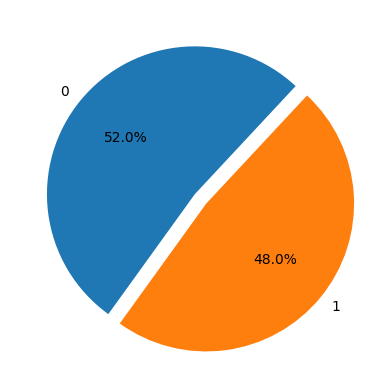

In [7]:
plt.pie(
    [y[y==0].shape[0], y[y==1].shape[0]],
    autopct='%1.1f%%',
    explode=(0, 0.1),
    labels=['0', '1'],
    startangle=47
)
plt.show();

In [8]:
unique, counts = np.unique(y, return_counts=True)
print(f"Класс 0 : {counts[0]}")
print(f"Класс 1 : {counts[1]}")

Класс 0 : 37440
Класс 1 : 34560


In [9]:
unique_counts = pd.DataFrame.from_records([(col, X[col].unique(), X[col].nunique(), X[col].dtypes) for col in X.columns],
                                          columns=['Name', 'Values', 'Count of values', 'Type']).sort_values(by=['Count of values', 'Name'])
unique_counts

,Name,Values,Count of values,Type
57,protocol,"[6, 17]",2,int64
54,dst_ip,"[d7da75db715e, 2a39f1eedcd9, 205301ef6a9d]",3,object
28,fin_flag_cnt,"[0, 1, 2, 3, 5, 4, 6, 7, 14]",9,int64
30,rst_flag_cnt,"[0, 1, 2, 3, 6, 5, 20, 4, 7, 16, 15, 13, 12, 1...",39,int64
18,fwd_psh_flags,"[0, 1, 2, 10, 3, 4, 6, 8, 12, 24, 5, 9, 16, 7,...",62,int64
...,...,...,...,...
0,flow_duration,"[41779773.047, 15264.0193, 141566.2355, 125146...",71997,float64
47,active_min,"[143133.6188, 74236.2105, 138641.2932, 12799.5...",71998,float64
17,bwd_iat_mean,"[24403181.9181, 5277.4966, 3441.5979, 1320592....",71998,float64
46,active_max,"[7240689.0504, 30623.4407, 308668.714, 7921690...",72000,float64


In [10]:
cat_cols = [
    'protocol',
    'src_ip', 'dst_ip',
    'src_port', 'dst_port',
    'fwd_psh_flags', 'fin_flag_cnt', 'syn_flag_cnt', 'rst_flag_cnt',
    'psh_flag_cnt', 'ack_flag_cnt', 'flag_anomaly_score'
]

num_cols = [col for col in X.columns if col not in cat_cols]